In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer

In [18]:
data = pd.read_csv("data/train.csv")
data.head()

,id,Age,BodyweightKg,MeetYear,Sex,Equipment,AgeClass,BirthYearClass,WeightClassKg,Tested,Country,State,Federation,ParentFederation,MeetCountry,MeetState,Sanctioned,TotalKg
0,27822,16.5,65.25,2016,M,Single-ply,16-17,14-18,66,Yes,Russia,Unknown,FPR,IPF,Russia,KLU,Yes,500.0
1,85202,27.0,88.50,2022,M,Raw,24-34,24-39,90,Untested,USA,IL,USPA,IPL,USA,IL,Yes,512.5
2,42217,29.5,92.30,2018,F,Raw,24-34,24-39,84+,Yes,USA,MA,USAPL,IPF,USA,MA,Yes,360.0
3,119958,27.0,52.00,2019,F,Single-ply,24-34,24-39,52,Yes,Russia,Unknown,WPC,WPC,Russia,ROS,Yes,362.5
4,37678,52.5,117.50,2025,M,Single-ply,50-54,50-59,125,Yes,USA,MI,USAPL,Unknown,USA,OH,Yes,355.0


In [19]:
data.isnull().sum()

id                  0
Age                 0
BodyweightKg        0
MeetYear            0
Sex                 0
Equipment           0
AgeClass            0
BirthYearClass      0
WeightClassKg       0
Tested              0
Country             0
State               0
Federation          0
ParentFederation    0
MeetCountry         0
MeetState           0
Sanctioned          0
TotalKg             0
dtype: int64

In [ ]:
X = data.drop(columns=["TotalKg"])
X = X[["Age","BodyweightKg","Sex"]]
Y = data["TotalKg"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_cols,
        ),
    ]
)


X_train_normed = preprocessor.fit_transform(X_train)
X_test_normed = preprocessor.transform(X_test)

X


/var/folders/_x/n95gs3252rgc51_6w0jltchc0000gn/T/ipykernel_99987/1633830766.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns


,Age,BodyweightKg,Sex
0,16.5,65.25,M
1,27.0,88.50,M
2,29.5,92.30,F
3,27.0,52.00,F
4,52.5,117.50,M
...,...,...,...
104995,25.0,51.50,F
104996,40.0,65.68,F
104997,21.5,92.50,M
104998,37.0,53.90,F


In [22]:
lr_model = LinearRegression(fit_intercept=False)

lr_model.fit(X_train_normed, Y_train)

lr_model.score(X_train_normed, Y_train)

0.6084205989524427

In [23]:
n = len(Y_test)

pred_test = lr_model.predict(X_test_normed)

MSE = 1/n * ((Y_test - pred_test).T @ (Y_test - pred_test))

print(MSE)

11423.016673805556


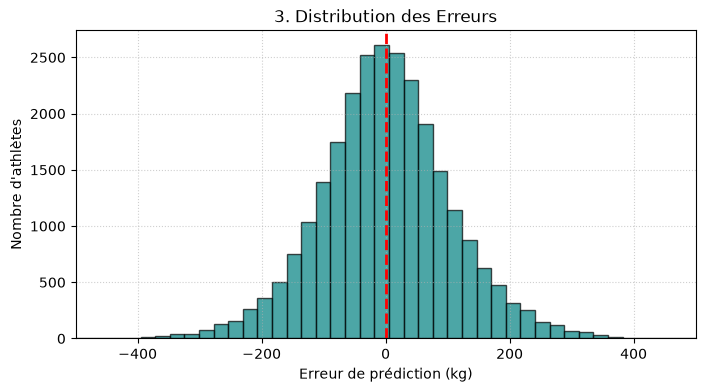

In [30]:
y_true = Y_test
y_pred = pred_test

y_true_arr = np.asarray(y_true).ravel()
y_pred_arr = np.asarray(y_pred).ravel()
residuals = y_true_arr - y_pred_arr


#q_low, q_high = np.percentile(residuals, [0.5, 99.5])
#max_limit = max(abs(q_low), abs(q_high))
#xmin, xmax = -max_limit, max_limit

xmin, xmax = -500, 500

fig, axes = plt.subplots(1, 1, figsize=(8, 4))

axes.hist(residuals, bins=60, color="teal", edgecolor="black", alpha=0.7)
axes.axvline(0, color="red", linestyle="--", lw=2)
axes.set_xlabel("Erreur de prédiction (kg)")
axes.set_ylabel("Nombre d'athlètes")
axes.set_title("3. Distribution des Erreurs")
axes.grid(True, linestyle=":", alpha=0.6)
axes.set_xlim(xmin, xmax)

plt.show()

In [33]:
data_test = pd.read_csv("data/test.csv")

X_test = data_test[["Age","BodyweightKg","Sex"]]

num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

X_train_normed = preprocessor.fit_transform(X_train)
X_test_normed = preprocessor.transform(X_test)

id = data_test[["id"]]
pred_test = lr_model.predict(X_test_normed)

submission = pd.DataFrame({
    "id": data_test["id"],
    "TotalKg": pred_test.flatten() 
})

submission.to_csv("lr_submission.csv", index=False)


/var/folders/_x/n95gs3252rgc51_6w0jltchc0000gn/T/ipykernel_99987/2462762269.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns
